# 02 — Layer 1: Default-Risk Models

Exactly **two** models (scope frozen, `DESIGN_FREEZE.md` §5):

1. **WOE + Logistic Regression** — scorecard-style interpretable baseline.
   WOE binning handles skew/outliers, gives missing values a learned bin,
   and yields IV as a per-feature strength summary a validator can audit.
   Count features use FIXED interpretable groups (0 / 1 / 2 / 3+ / missing);
   all numeric edges are open-ended so an unseen extreme value (say 25 past
   90-day delinquencies) lands in the highest-risk tail bin, never in a
   neutral bucket. The scorecard has its own feature list: flags that merely
   duplicate a WOE missing bin are excluded (collinearity, not information).
2. **Monotonic LightGBM** — challenger. LightGBM over XGBoost because native
   NaN handling matches our cleaning rules (sentinels/invalids → NaN + flag)
   and `monotone_constraints` are first-class. PD is constrained
   non-decreasing in capped utilization and the three delinquency counts:
   robustness in sparse regions, business trust (a score must not fall when
   delinquencies rise), and a *testable* validation property
   (`tests/test_monotonic.py`). This is governance-**aware** — real
   governance would also need stability monitoring, fairness analysis, and
   documentation beyond this project's scope; we claim none of that.

**Evaluation discipline.** All selection (WOE bins, imputation constants,
hyperparameters) is nested inside training data (§3). The **primary
generalization evidence is the nested outer 5-fold CV on RISK-DEV**;
RISK-TEST serves as a **fixed secondary holdout diagnostic**. It is not
pristine — its labels informed early full-population EDA in aggregate, and
it was re-evaluated once after a binning bug fix — both disclosed in the
`DESIGN_FREEZE.md` amendment log. Honest accounting of holdout usage beats
an "untouched test set" narrative that no longer holds. This notebook only
*reads* artifacts produced by `python -m src.run_layer1`.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src import config  # noqa: E402

ART = config.ARTIFACTS_DIR
FIG = config.FIGURES_DIR
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## Primary generalization evidence: nested outer CV (RISK-DEV)

Each fold's hyperparameters were re-tuned inside that fold's training data,
so the table below reports the stability of the *whole procedure*, not of
one lucky configuration. These numbers — not the holdout — are the basis for
model selection (including carrying LightGBM into the Linkage phase).

In [2]:
stab = pd.read_csv(ART / "stability_outer_cv.csv")
stab_summary = (stab.groupby("model")[["roc_auc", "pr_auc", "ks", "brier"]]
                .agg(["mean", "std"]).round(4))
display(stab_summary)
display(stab[["fold", "model", "roc_auc", "ks",
              "chosen_C", "chosen_num_leaves", "chosen_n_estimators"]])

roc_auc        pr_auc            ks         brier       
             mean    std   mean    std   mean    std   mean    std
model                                                             
lgbm_mono  0.8654 0.0054 0.3967 0.0158 0.5749 0.0129 0.0493 0.0008
lr_woe     0.8559 0.0063 0.3743 0.0153 0.5544 0.0142 0.0505 0.0008

,fold,model,roc_auc,ks,chosen_C,chosen_num_leaves,chosen_n_estimators
0,0,lr_woe,0.8599,0.5629,0.1000,NaN,NaN
1,0,lgbm_mono,0.8687,0.5859,NaN,15.0000,120.0000
2,1,lr_woe,0.8498,0.5399,0.1000,NaN,NaN
3,1,lgbm_mono,0.8592,0.5640,NaN,63.0000,93.0000
4,2,lr_woe,0.8645,0.5738,0.1000,NaN,NaN
5,2,lgbm_mono,0.8729,0.5895,NaN,31.0000,116.0000
6,3,lr_woe,0.8553,0.5527,0.1000,NaN,NaN
7,3,lgbm_mono,0.8640,0.5603,NaN,31.0000,104.0000
8,4,lr_woe,0.8502,0.5427,0.1000,NaN,NaN
9,4,lgbm_mono,0.8622,0.5749,NaN,31.0000,120.0000


## Secondary holdout diagnostic: RISK-TEST (fixed, reused, disclosed)

In [3]:
final = json.loads((ART / "final_test_metrics.json").read_text())
final_df = pd.DataFrame({k: v for k, v in final.items() if k != "note"}).T
display(final_df[["roc_auc", "pr_auc", "ks", "brier", "n", "event_rate"]])
print(final["note"])

,roc_auc,pr_auc,ks,brier,n,event_rate
lr_woe,0.8514,0.3869,0.5478,0.0499,"30,000.0000",0.0668
lgbm_mono,0.8595,0.4047,0.5692,0.0488,"30,000.0000",0.0668


RISK-TEST evaluated on the primary spec only; see DESIGN_FREEZE.md amendment log for the one documented re-evaluation (WOE binning bug fix)


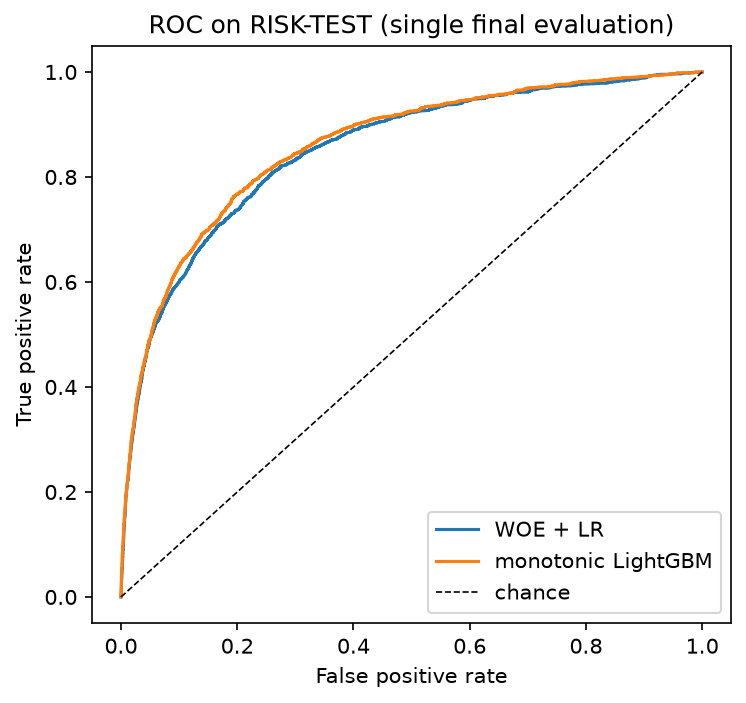

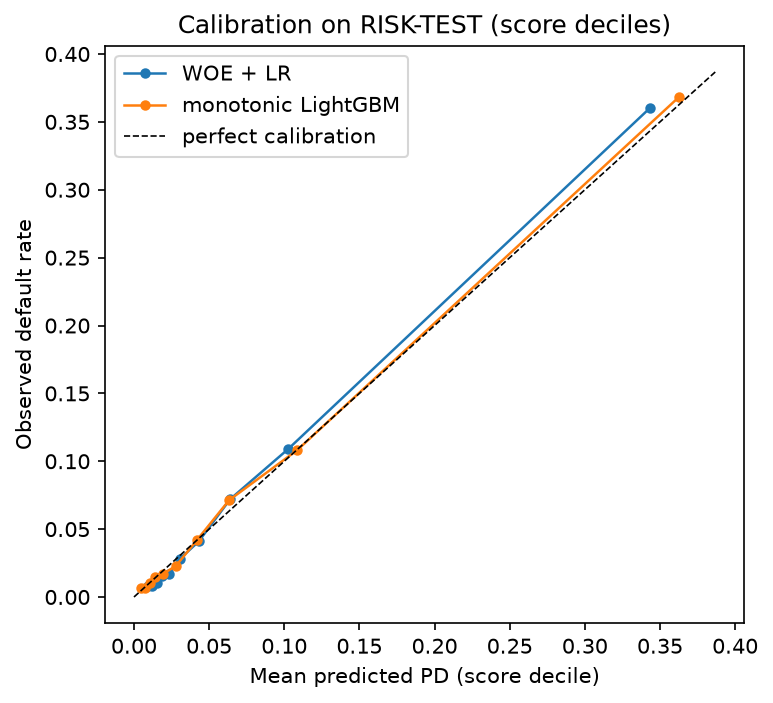

In [4]:
display(Image(str(FIG / "roc_test.png")))
display(Image(str(FIG / "calibration_test.png")))

**Leakage checks and interpretation.** The retained CV and holdout metrics
are broadly similar, but agreement alone does not rule out leakage. This
local holdout is not the competition's private leaderboard sample. The
behavioral tests and the disclosed holdout-use history are the relevant
evidence for this implementation.

The sanity hunt also runs in the other direction: in the first Layer-1 run,
IV(NumberOfTimes90DaysLate) came out at 0.04 — flatly contradicting domain
knowledge (a 90-day delinquency is one of the strongest default predictors
anywhere). Root cause: on a 94.6%-zero count feature, every interior
quantile edge equals 0, so the WOE binning silently collapsed all
non-missing rows into a single bin. Fixed (per-value bins for
low-cardinality features + a collapse guard), covered by a regression test
(`test_zero_inflated_count_feature_is_not_collapsed`), and the pipeline was
re-run — **including a second RISK-TEST evaluation, disclosed in the
`DESIGN_FREEZE.md` amendment log** rather than quietly absorbed. A metric
that looks too *bad* against domain priors deserves the same suspicion as
one that looks too good.

A repo audit later found a second discipline breach: v1 of the EDA notebook
computed target-aware statistics (segment default rates, sentinel risk) on
the FULL population, so holdout labels informed exploratory judgment in
aggregate. Remedied by dev-only SQL views + the reframing above; also in the
amendment log. The through-line of both incidents: when a claim ("untouched
holdout") stops being true, we change the claim, not the story.

**Calibration.** The scorecard LR is naturally close to calibrated; the
GBDT's raw scores are usable but Layers 2–3 consume *cross-fitted,
cross-calibrated* OOF scores produced in the Linkage phase — raw test-set
calibration here is a Layer-1 diagnostic, not the product.

## WOE / Information Value

,IV
RevolvingUtilizationOfUnsecuredLines,1.1035
NumberOfTimes90DaysLate,0.8664
NumberOfTime30-59DaysPastDueNotWorse,0.7625
NumberOfTime60-89DaysPastDueNotWorse,0.5960
age,0.2611
NumberOfOpenCreditLinesAndLoans,0.0811
MonthlyIncome,0.0732
DebtRatio,0.0560
NumberRealEstateLoansOrLines,0.0559
NumberOfDependents,0.0352


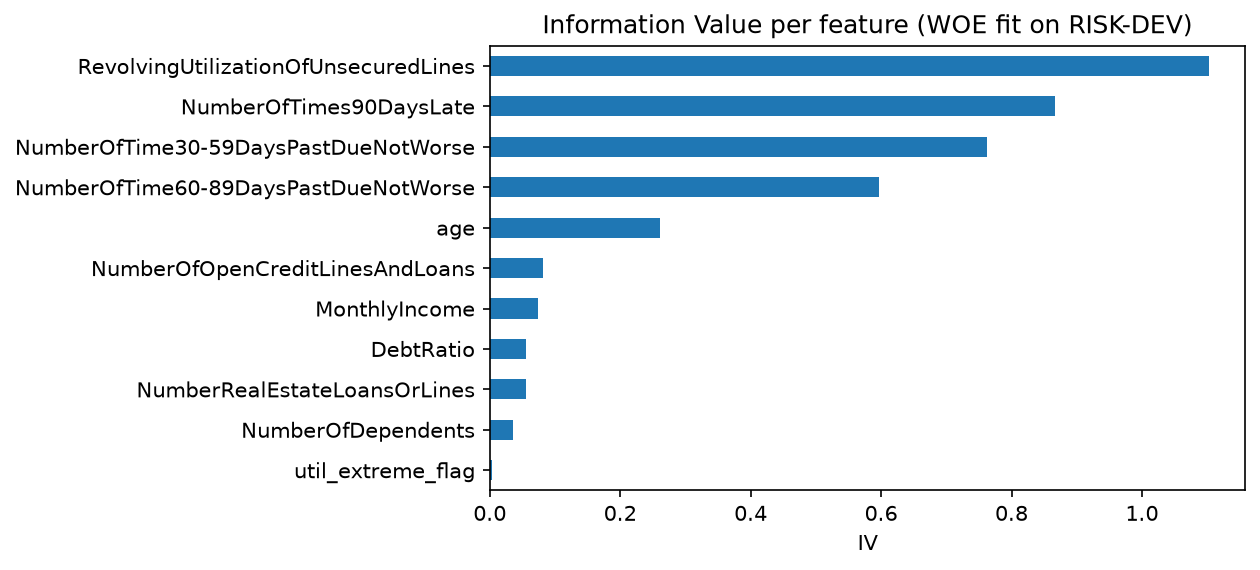

In [5]:
iv = pd.read_csv(ART / "iv_table.csv", index_col=0)
display(iv)
display(Image(str(FIG / "iv_ranking.png")))

In [6]:
# Example WOE bin table: utilization (the strongest feature)
woe_bins = pd.read_csv(ART / "woe_bins.csv")
display(woe_bins[woe_bins["feature"] == "RevolvingUtilizationOfUnsecuredLines"])

,feature,bin,events,n,non_events,woe,event_rate,iv_contrib
0,RevolvingUtilizationOfUnsecuredLines,0,335,15000,14665,1.1418,0.0223,0.1018
1,RevolvingUtilizationOfUnsecuredLines,1,208,15000,14792,1.6262,0.0139,0.1726
2,RevolvingUtilizationOfUnsecuredLines,2,249,15000,14751,1.4439,0.0166,0.1453
3,RevolvingUtilizationOfUnsecuredLines,3,336,15000,14664,1.1388,0.0224,0.1014
4,RevolvingUtilizationOfUnsecuredLines,4,550,15000,14450,0.6319,0.0367,0.0382
5,RevolvingUtilizationOfUnsecuredLines,5,976,15000,14024,0.0288,0.0651,0.0001
6,RevolvingUtilizationOfUnsecuredLines,6,1988,15000,13012,-0.7573,0.1325,0.0996
7,RevolvingUtilizationOfUnsecuredLines,7,3379,15000,11621,-1.4007,0.2253,0.4445


Conventional IV reading: > 0.3 = strong, 0.1–0.3 = medium. Utilization and
the delinquency counts dominate — consistent with the segment EDA and with
how the monotone constraints were chosen.

## Sensitivity analyses (CV on RISK-DEV only — RISK-TEST untouched)

Hyperparameters held at the primary spec's values so differences isolate the
cleaning rule. `sentinel_drop` trains without sentinel rows but is still
*evaluated* on everyone (a deployed model cannot drop applicants).

In [7]:
sens = pd.read_csv(ART / "sensitivity_cv.csv")
sens_summary = (sens.groupby(["variant", "model"])[["roc_auc", "ks"]]
                .agg(["mean", "std"]).round(4))
display(sens_summary)

roc_auc            ks       
                           mean    std   mean    std
variant       model                                 
primary       lgbm_mono  0.8658 0.0053 0.5752 0.0142
              lr_woe     0.8559 0.0063 0.5544 0.0142
sentinel_cap  lgbm_mono  0.8657 0.0052 0.5750 0.0141
              lr_woe     0.8560 0.0063 0.5544 0.0144
sentinel_drop lgbm_mono  0.8646 0.0053 0.5745 0.0128
              lr_woe     0.8562 0.0063 0.5557 0.0135
util_missing  lgbm_mono  0.8660 0.0052 0.5759 0.0147
              lr_woe     0.8559 0.0062 0.5544 0.0137
util_p99      lgbm_mono  0.8657 0.0052 0.5756 0.0141
              lr_woe     0.8559 0.0063 0.5544 0.0142

## SHAP explainability (monotonic LightGBM)

**Framing:** these are *illustrative local risk explanations / a candidate
reason-code mapping*. They are **not** validated adverse-action notices —
real adverse-action reason codes require validated mappings, regulatory
review, and consistency testing far beyond a SHAP plot.

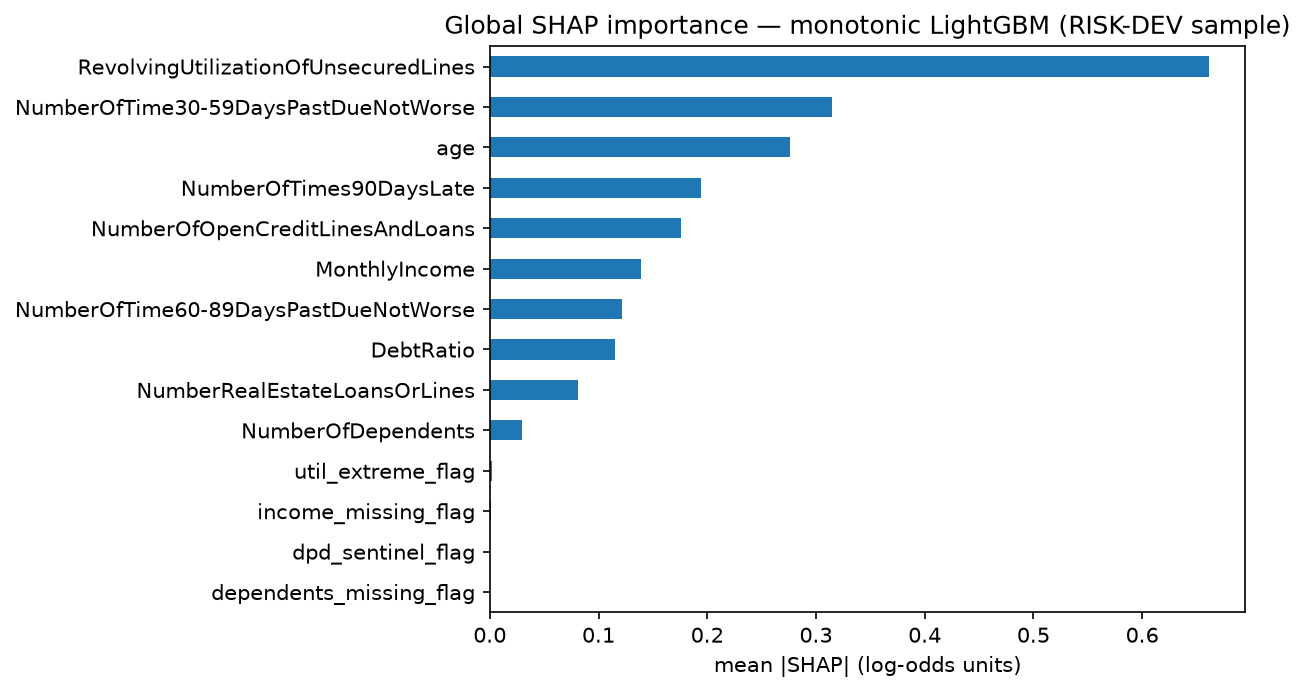

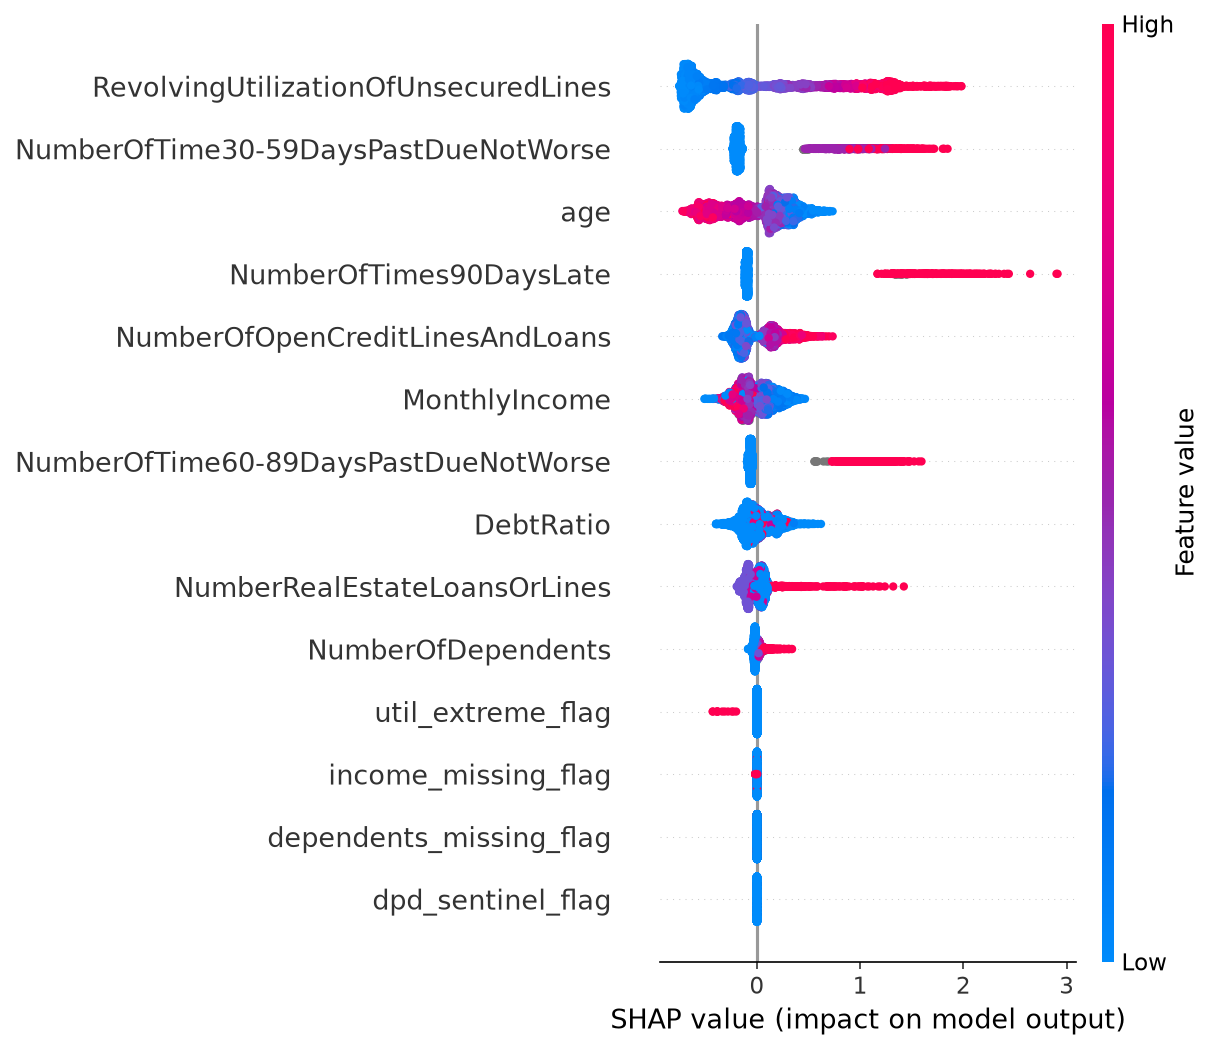

In [8]:
display(Image(str(FIG / "shap_global_bar.png")))
display(Image(str(FIG / "shap_beeswarm_lgbm.png")))

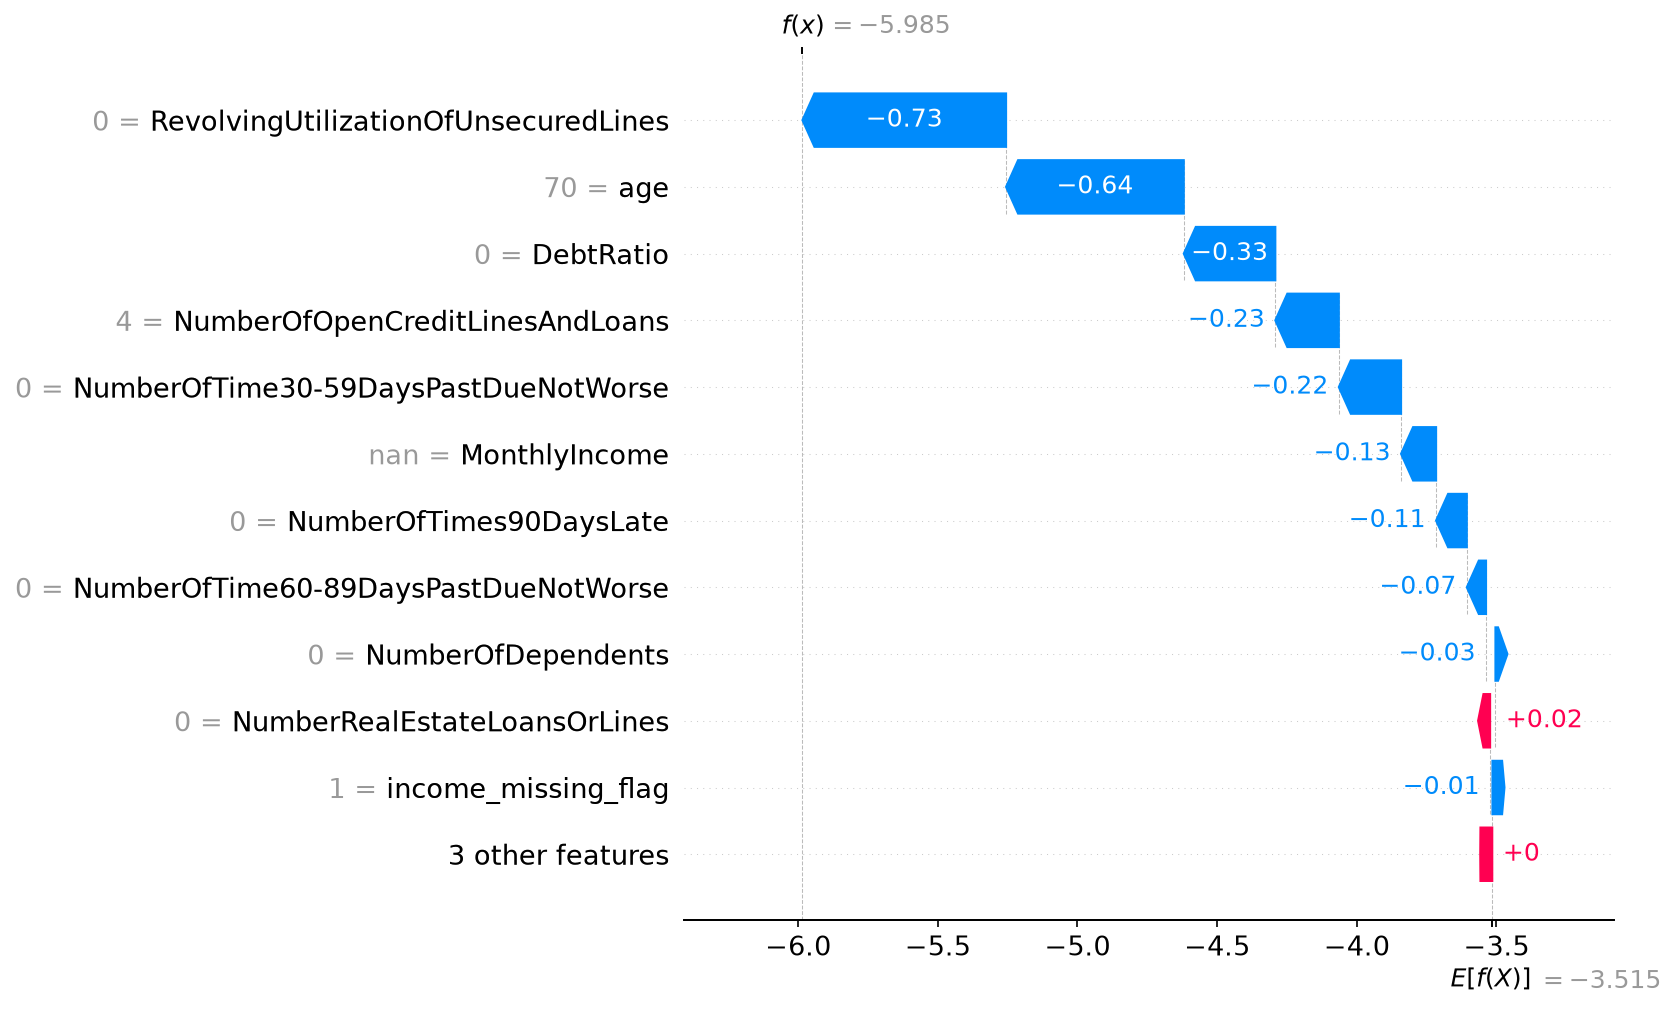

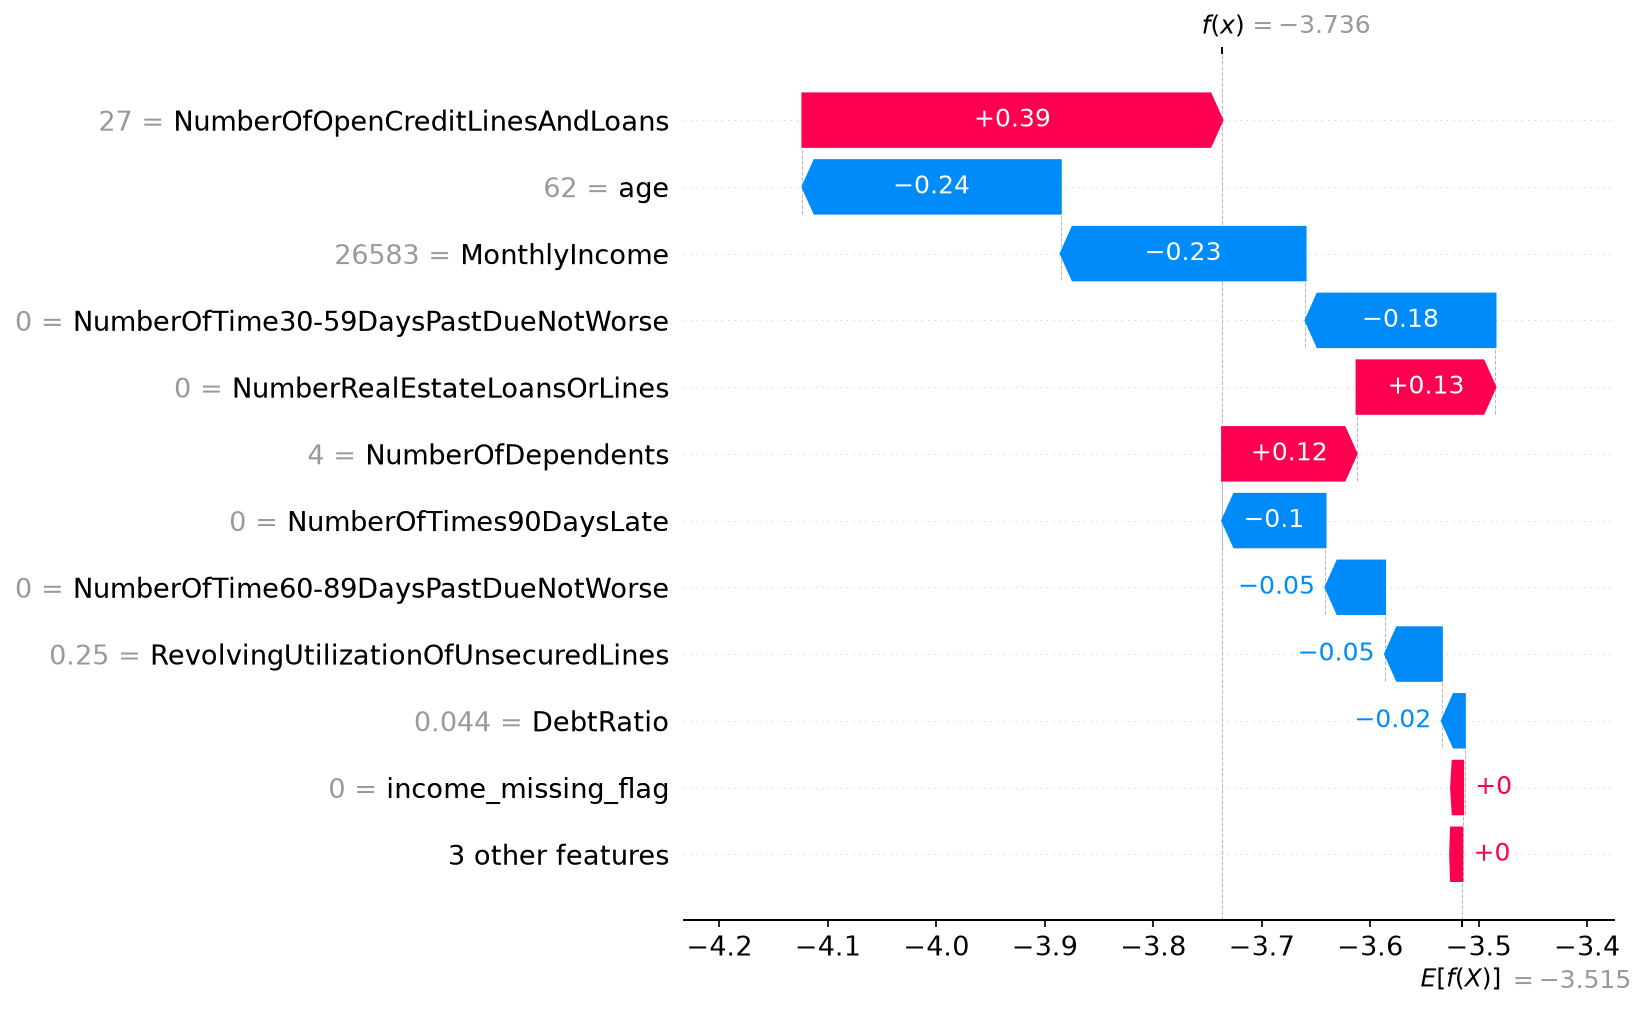

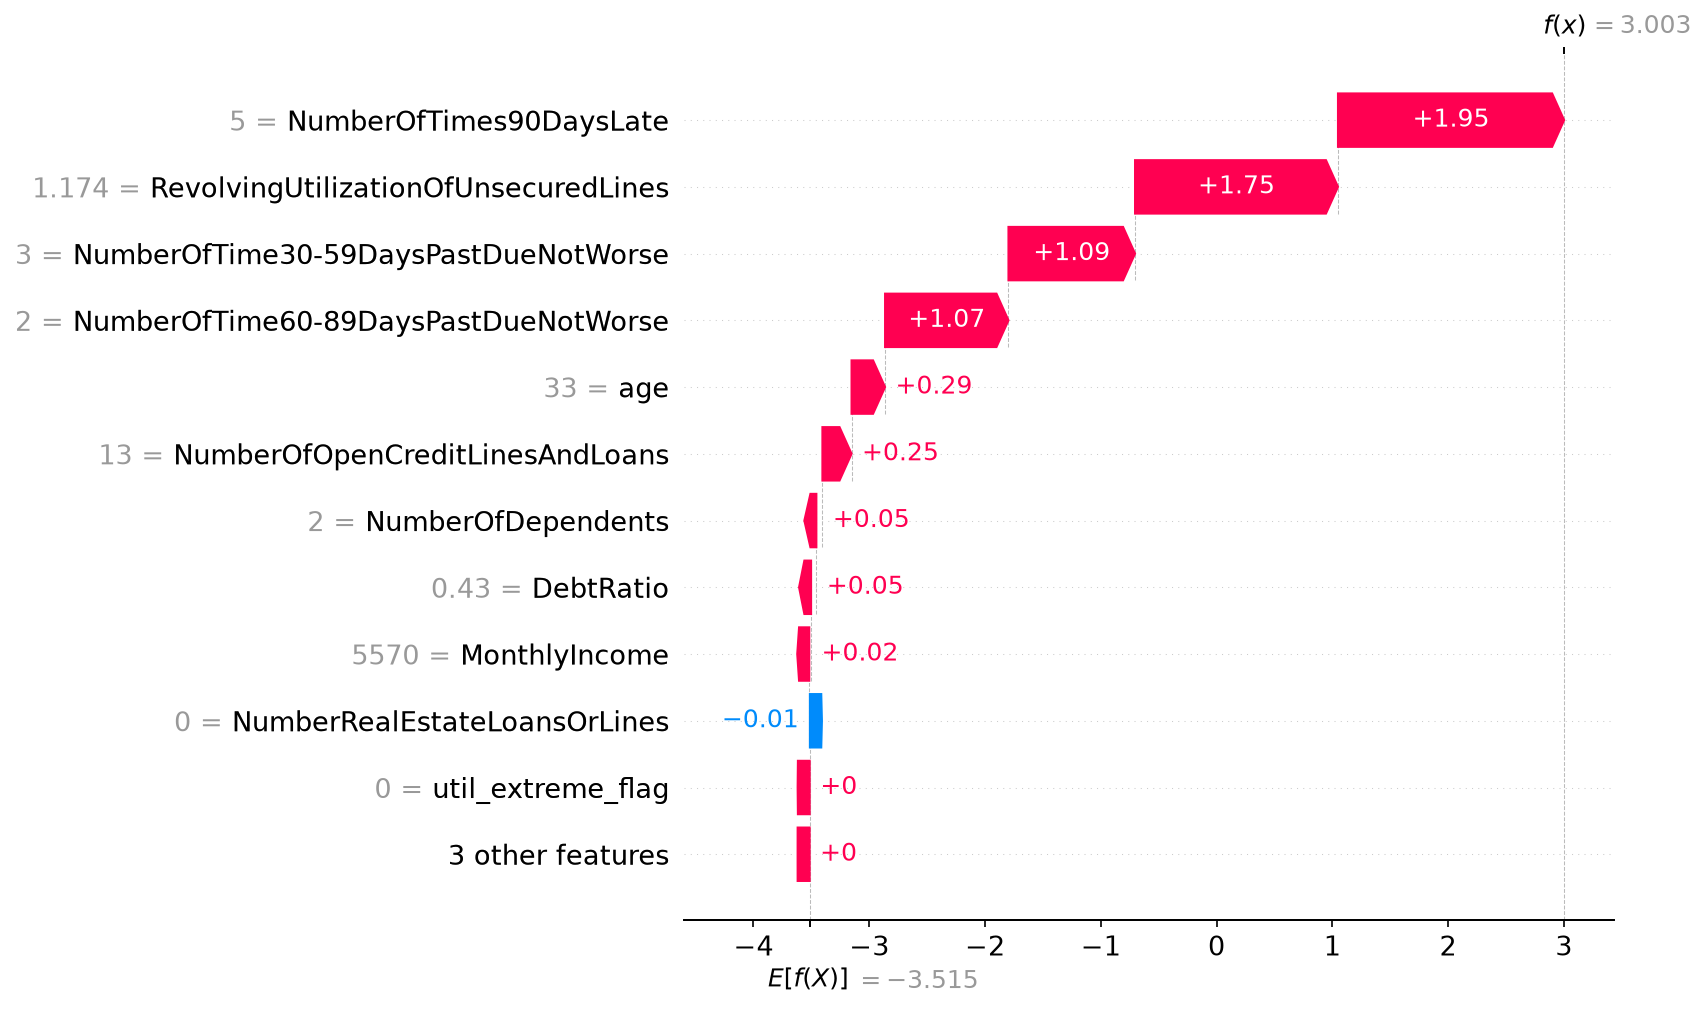

In [9]:
for tag in ("low", "median", "high"):
    display(Image(str(FIG / f"shap_local_{tag}_risk.png")))

### SHAP vs IV ranking

In [10]:
comp = pd.read_csv(ART / "shap_vs_iv_ranking.csv", index_col=0)
display(comp)

,iv_rank,shap_rank,iv,mean_abs_shap
RevolvingUtilizationOfUnsecuredLines,1.0000,1.0000,1.1035,0.6619
NumberOfTime30-59DaysPastDueNotWorse,3.0000,2.0000,0.7625,0.3143
age,5.0000,3.0000,0.2611,0.2760
NumberOfTimes90DaysLate,2.0000,4.0000,0.8664,0.1946
NumberOfOpenCreditLinesAndLoans,6.0000,5.0000,0.0811,0.1762
MonthlyIncome,7.0000,6.0000,0.0732,0.1391
NumberOfTime60-89DaysPastDueNotWorse,4.0000,7.0000,0.5960,0.1217
DebtRatio,8.0000,8.0000,0.0560,0.1147
NumberRealEstateLoansOrLines,9.0000,9.0000,0.0559,0.0812
NumberOfDependents,10.0000,10.0000,0.0352,0.0297


IV ranks features by *univariate* separation after binning; SHAP ranks
*multivariate* contribution inside the fitted GBDT. Agreement at the top
(utilization, delinquency counts) is reassuring. Divergence lower down is
expected: correlated features share SHAP credit, and a feature with modest
IV can matter in interactions (or vice versa). Where the two disagree, the
scorecard view (IV) is the one a model validator would start from — another
reason to keep the WOE+LR baseline alongside the GBDT.